# 🎬 Netflix Data Analysis

## Section 0 — Import Library And Load the Netflix Dataset 

In [1]:
# Import The Libraries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

##  Section 1 — Problem Statement & Basic Metrics

### 1.1 Problem Statement

Netflix operates a vast content library spanning movies and TV shows across genres, countries, and ratings. This analysis aims to:

- **Understand** the composition and growth of the Netflix catalog
- **Identify** dominant content types, countries, genres, and ratings
- **Detect** data quality issues (missing values, outliers, encoding errors)
- **Uncover** seasonal and yearly trends in content addition
- **Derive** actionable business recommendations for content strategy

In [2]:
# Load the Netflix data Csv File 
data = pd.read_csv('netflix.csv')

print(f"Dataset loaded!")
print(f"   We have {data.shape[0]} rows and {data.shape[1]} columns.")
print(f"   That means {data.shape[0]} Netflix titles and {data.shape[1]} pieces of info about each title.")
data.head(3)

Dataset loaded!
   We have 8807 rows and 12 columns.
   That means 8807 Netflix titles and 12 pieces of info about each title.


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


## 🔍 Section 2 — Data Shape, Types, Conversions, Missing Values & Statistical Summary

In [3]:
# shape tells us (number of rows, number of columns)
rows, cols = data.shape
print(f"The dataset has:")
print(f"  → {rows} rows    (each row = one Netflix title)")
print(f"  → {cols} columns (each column = one piece of information)")

The dataset has:
  → 8807 rows    (each row = one Netflix title)
  → 12 columns (each column = one piece of information)


In [4]:
# Data Info 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
# Convert categorical columns
# There are 3 rows where a duration value was accidentally put in the rating column
# Fix rating encoding errors first (3 rows have duration values in rating)
data['rating'] = data['rating'].replace({'74 min': np.nan, '84 min': np.nan, '66 min': np.nan})

In [6]:
# Convert to category
for col in ['type', 'rating']:
    data[col] = data[col].astype('category')
print('Conversions applied:-')
print('  - rating, type → category')

Conversions applied:-
  - rating, type → category


In [7]:
# Parse date
data['date_added'] = pd.to_datetime(data['date_added'], errors='coerce')
data['year_added']  = data['date_added'].dt.year
data['month_added'] = data['date_added'].dt.month
data['month_name']  = data['date_added'].dt.strftime('%b')

print('Conversions applied:-')
print('  - date_added   → datetime; extracted year_added, month_added, month_name')

Conversions applied:-
  - date_added   → datetime; extracted year_added, month_added, month_name


In [8]:
# Extract numeric duration
data['duration_num'] = data['duration'].str.extract(r'(\d+)').astype(float)
data['duration_mins']   = np.where(data['type'] == 'Movie',   data['duration_num'], np.nan)
data['seasons']         = np.where(data['type'] == 'TV Show', data['duration_num'], np.nan)

print('Conversions applied:-')
print('  - duration → duration_mins (movies), seasons (TV shows)')

Conversions applied:-
  - duration → duration_mins (movies), seasons (TV shows)


In [9]:
print('Updated dtypes:')
print(data[['type','rating','date_added','duration_mins','seasons']].dtypes)

Updated dtypes:
type                   category
rating                 category
date_added       datetime64[ns]
duration_mins           float64
seasons                 float64
dtype: object


In [10]:
# Missing Value Detection
missing = data.isnull().sum()
missing_pct = (data.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print('Missing Values:')
print(missing_df.to_string())

Missing Values:
               Missing Count  Missing %
seasons                 6131      69.62
duration_mins           2679      30.42
director                2634      29.91
country                  831       9.44
cast                     825       9.37
date_added                98       1.11
year_added                98       1.11
month_added               98       1.11
month_name                98       1.11
rating                     7       0.08
duration                   3       0.03
duration_num               3       0.03


In [11]:
#Statistical Summary
print('Statistical Summary — Numerical Columns:')
data[['release_year', 'duration_mins', 'seasons']].describe().round(2)

Statistical Summary — Numerical Columns:


,release_year,duration_mins,seasons
count,8807.00,6128.00,2676.00
mean,2014.18,99.58,1.76
std,8.82,28.29,1.58
min,1925.00,3.00,1.00
25%,2013.00,87.00,1.00
50%,2017.00,98.00,1.00
75%,2019.00,114.00,2.00
max,2021.00,312.00,17.00


## 📊 Section 3 — Non-Graphical Analysis: Value Counts & Unique Attributes

In [12]:
# How many Movies vs TV Shows are there?
print('Content Type — Value Counts:')
print(data['type'].value_counts())

Content Type — Value Counts:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [13]:
# What ratings does Netflix content have?
print('Rating — Value Counts:')
print(data['rating'].value_counts())

Rating — Value Counts:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [14]:
# Which countries produce the most Netflix content?
# Some rows have multiple countries like "United States, India"
# So we SPLIT them to count each country separately

# Split the country column and explode it into individual rows
data['country_split'] = data['country'].str.split(',') # split "France, Senegal, Belgium" -> [France,Sengal,Belgium]
exploded = data.explode('country_split')             # each country gets its own row
exploded['country_split'] = exploded['country_split'].str.strip()  # remove extra spaces

In [15]:
# Use groupby to count each country
country_counts = exploded.groupby('country_split')['show_id'].count()

# Sort from highest to lowest
country_counts = country_counts.sort_values(ascending=False)

In [16]:
# Show the results
print('Top 12 Countries (using groupby):')
print(country_counts.head(12))
print(f'\nTotal unique countries: {len(country_counts)}')

Top 12 Countries (using groupby):
country_split
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Name: show_id, dtype: int64

Total unique countries: 123


In [17]:
# What genres are most popular?
# Same idea — split comma-separated genres and count each one

# Split the 'listed_in' column by comma into a list
data['genre_split'] = data['listed_in'].str.split(',')    # "Dramas, Comedies" → ['Dramas', 'Comedies']

# Explode — each genre gets its own row
genres = data.explode('genre_split')                 # one genre per row now

# Clean up extra spaces
genres['genre_split'] = genres['genre_split'].str.strip()

# Use groupby to count each genre
genre_counts_gb = genres.groupby('genre_split')['show_id'].count()

# Step 5: Sort from highest to lowest
genre_counts_gb = genre_counts_gb.sort_values(ascending=False)

# Step 6: Show the results
print('Top 15 Genres (Using groupby):')
print(genre_counts_gb.head(15))
print(f'\nTotal unique genres: {len(genre_counts_gb)}')

Top 15 Genres (Using groupby):
genre_split
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: show_id, dtype: int64

Total unique genres: 42


In [18]:
#  Which directors have the most content on Netflix?
top_directors = data['director'].value_counts()
print('Top 10 Most Prolific Directors:')
print(top_directors.head(10))
print(f'\nTotal unique directors: {len(top_directors):,}')

Top 10 Most Prolific Directors:
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

Total unique directors: 4,528


In [19]:
# 3.4 Unique attribute summary
print('Unique Value Counts per Attribute:')

for col in data.columns:
    try:
        unique_vals = data[col].nunique()
    except TypeError:
        unique_vals = data[col].apply(str).nunique()  # handle lists
    
    missing_vals = data[col].isnull().sum()
    
    print(f'  {col:<20}: {unique_vals:>6} unique values  |  {missing_vals:>4} missing')

Unique Value Counts per Attribute:
  show_id             :   8807 unique values  |     0 missing
  type                :      2 unique values  |     0 missing
  title               :   8807 unique values  |     0 missing
  director            :   4528 unique values  |  2634 missing
  cast                :   7692 unique values  |   825 missing
  country             :    748 unique values  |   831 missing
  date_added          :   1699 unique values  |    98 missing
  release_year        :     74 unique values  |     0 missing
  rating              :     14 unique values  |     7 missing
  duration            :    220 unique values  |     3 missing
  listed_in           :    514 unique values  |     0 missing
  description         :   8775 unique values  |     0 missing
  year_added          :     14 unique values  |    98 missing
  month_added         :     12 unique values  |    98 missing
  month_name          :     12 unique values  |    98 missing
  duration_num        :    210 uniq

## 📈 Section 4 — Visual Analysis (Univariate & Bivariate)

> **Pre-processing applied:** `date_added` parsed to datetime; `duration` split into `duration_mins` (movies) and `seasons` (TV shows); `country`, `listed_in`, `cast`, and `director` unnested from comma-separated strings.

### 4.1 Univariate — Continuous Variables (Distplot, Histogram, Countplot)

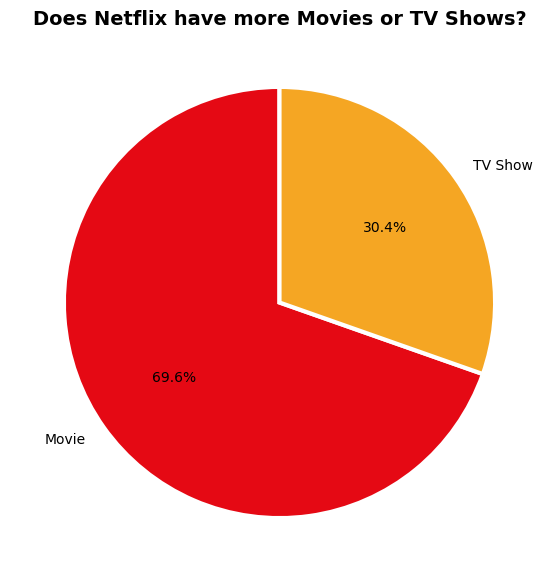

📝 What this chart tells us:
   Netflix has almost 70% Movies and only 30% TV Shows.
   Netflix started as a movie rental service — this history still shows!


In [20]:
# CHART 1: Pie chart — Movies vs TV Shows
# A pie chart is great for showing 'parts of a whole'

type_counts = data['type'].value_counts()

plt.figure(figsize=(7, 7))  # set the chart size

plt.pie(
    type_counts.values,        # the numbers
    labels=type_counts.index,  # the labels (Movie / TV Show)
    autopct='%1.1f%%',         # show percentages
    colors=['#E50914', '#F5A623'],  # Netflix red and orange
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 3}
)

plt.title('Does Netflix have more Movies or TV Shows?', fontsize=14, fontweight='bold')
plt.show()

# What we see:
print("📝 What this chart tells us:")
print("   Netflix has almost 70% Movies and only 30% TV Shows.")
print("   Netflix started as a movie rental service — this history still shows!")

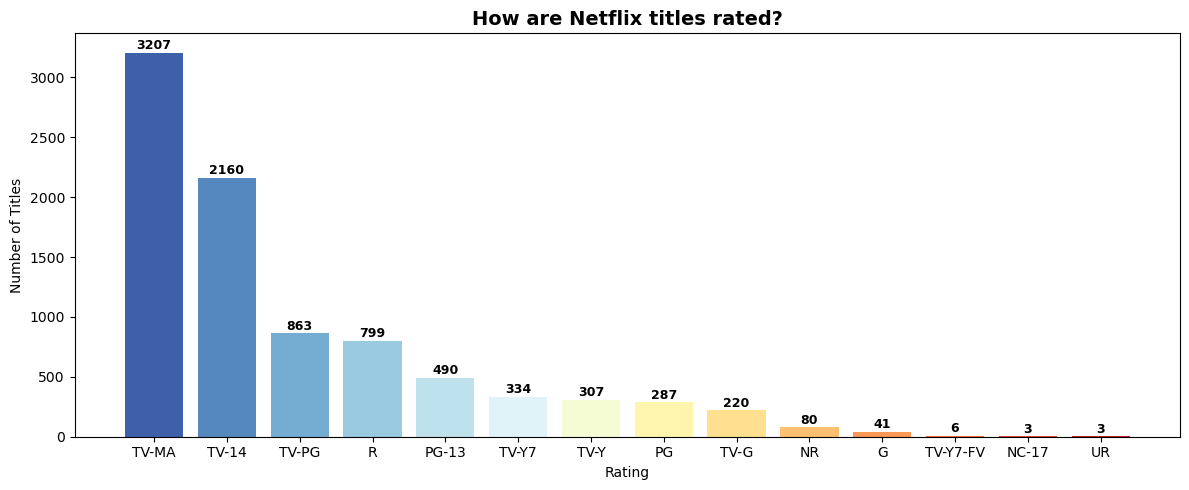

📝 What this chart tells us:
   TV-MA (Mature Audiences) is the most common rating.
   Netflix focuses heavily on adult content (TV-MA + TV-14 = about 61% of all titles).


In [21]:
# CHART 2: Bar chart — Content Ratings

rating_counts = data['rating'].value_counts().dropna()

plt.figure(figsize=(12, 5))

# Generate colors manually (fix for palette warning)
colors = sns.color_palette('RdYlBu_r', len(rating_counts))

plt.bar(
    rating_counts.index,
    rating_counts.values,
    color=colors
)

# Add count labels
for i, v in enumerate(rating_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontsize=9, fontweight='bold')

plt.title('How are Netflix titles rated?', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

print("📝 What this chart tells us:")
print("   TV-MA (Mature Audiences) is the most common rating.")
print("   Netflix focuses heavily on adult content (TV-MA + TV-14 = about 61% of all titles).")

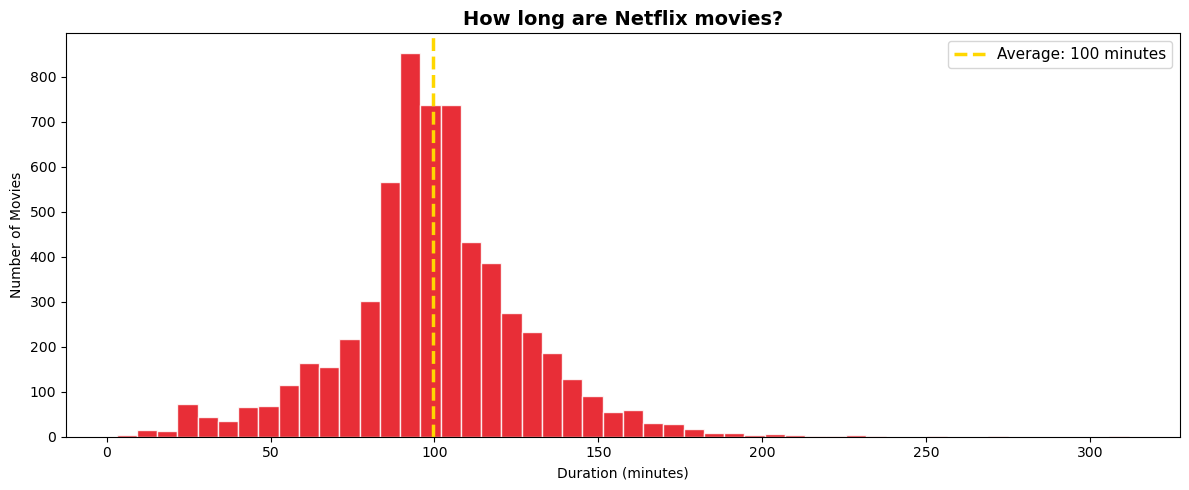

📝 What this chart tells us:
   Most Netflix movies are between 80–120 minutes long.
   The average movie is about 100 minutes (~1.7 hours).
   There are a few very long movies too (outliers on the right side)!


In [22]:
# CHART 3: Histogram — How long are Netflix movies?
# A histogram shows the DISTRIBUTION of a numeric value
# (how values spread out across a range)

movie_duration = data[data['type'] == 'Movie']['duration_mins'].dropna()

plt.figure(figsize=(12, 5))

plt.hist(
    movie_duration,
    bins=50,              # number of bars
    color='#E50914',      # Netflix red
    edgecolor='white',
    alpha=0.85
)

# Add a vertical line to show the average
avg = movie_duration.mean()
plt.axvline(avg, color='gold', linestyle='--', linewidth=2.5, label=f'Average: {avg:.0f} minutes')

plt.title('How long are Netflix movies?', fontsize=14, fontweight='bold')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("📝 What this chart tells us:")
print(f"   Most Netflix movies are between 80–120 minutes long.")
print(f"   The average movie is about {avg:.0f} minutes (~{avg/60:.1f} hours).")
print(f"   There are a few very long movies too (outliers on the right side)!")

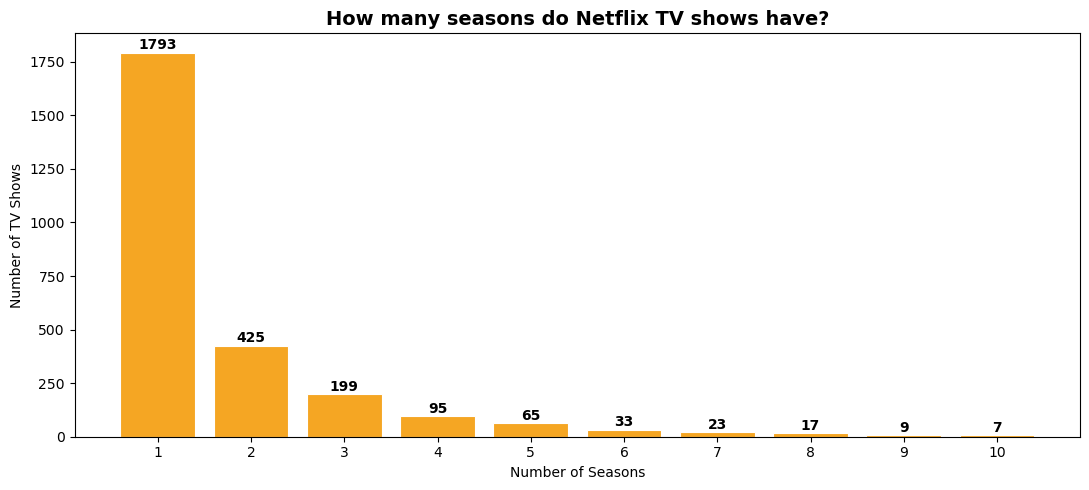

📝 What this chart tells us:
   1793 TV shows have only 1 season — that is 67% of all TV shows!
   Netflix loves short, limited-series shows.


In [23]:
# CHART 4: Count plot — How many seasons do TV shows have?
# A count plot is like a bar chart but counts occurrences automatically

tv_seasons = data[data['type'] == 'TV Show']['seasons'].dropna()
season_counts = tv_seasons.value_counts().sort_index().head(10)

plt.figure(figsize=(11, 5))

plt.bar(
    season_counts.index.astype(int),
    season_counts.values,
    color='#F5A623',
    edgecolor='white',
    linewidth=0.8
)

# Add count labels on top
for season, count in zip(season_counts.index, season_counts.values):
    plt.text(season, count + 15, str(count), ha='center', fontsize=10, fontweight='bold')

plt.title('How many seasons do Netflix TV shows have?', fontsize=14, fontweight='bold')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

print("📝 What this chart tells us:")
print(f"   {int(tv_seasons[tv_seasons==1].sum())} TV shows have only 1 season — that is {tv_seasons[tv_seasons==1].count()/len(tv_seasons)*100:.0f}% of all TV shows!")
print("   Netflix loves short, limited-series shows.")

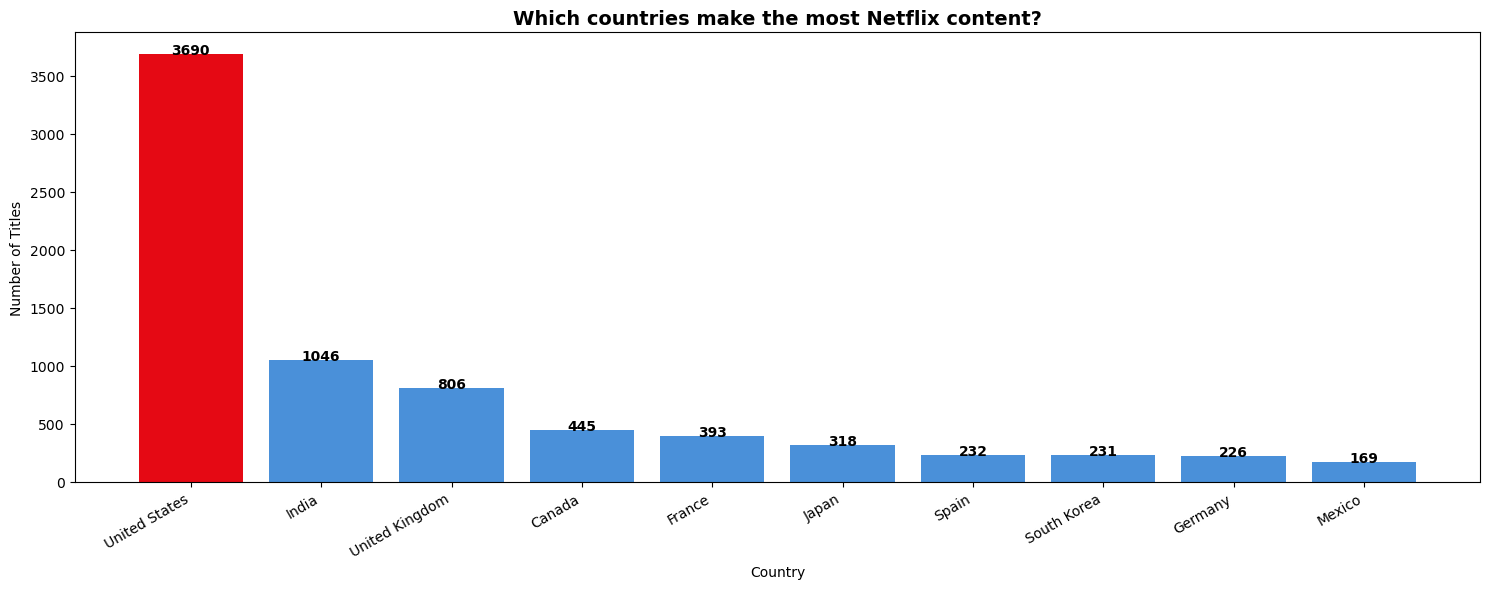

📝 What this chart tells us:
   The United States makes BY FAR the most content on Netflix.
   India is a strong #2, showing Netflix's big push into the Indian market.


In [24]:
# CHART 5: Bar chart — Top 10 countries
top_countries = country_counts.head(10)

plt.figure(figsize=(15, 6))
colors = ['#E50914'] + ['#4A90D9'] * 9  # red for #1, blue for rest
plt.bar(top_countries.index, top_countries.values,color = colors)

# Labels
for i, v in enumerate(top_countries.values):
    plt.text(i, v, str(v), ha='center',fontsize=10, fontweight='bold')

plt.title('Which countries make the most Netflix content?', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("📝 What this chart tells us:")
print("   The United States makes BY FAR the most content on Netflix.")
print("   India is a strong #2, showing Netflix's big push into the Indian market.")

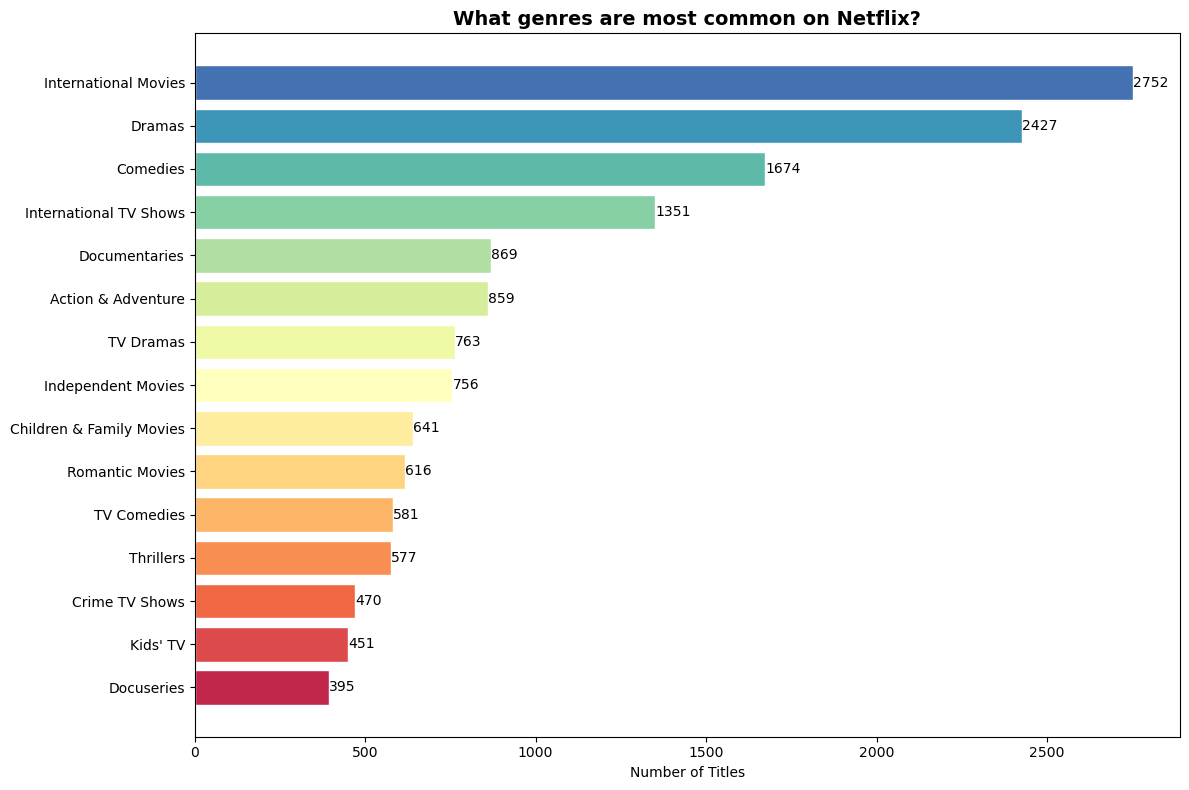

📝 What this chart tells us:
   International Movies, Dramas and Comedies are the top 3 genres.
   International content is Netflix's biggest category — a sign of its global strategy.


In [25]:
# CHART 6: Horizontal bar chart — Top 15 genres
top_genres = genre_counts_gb.sort_values(ascending=True).tail(15)

plt.figure(figsize=(12, 8))
colors_g = sns.color_palette('Spectral', len(top_genres))
plt.barh(top_genres.index, top_genres.values,color=colors_g, edgecolor='white')

# Labels
for i, v in enumerate(top_genres.values):
    plt.text(v, i, str(v), va='center')

plt.title('What genres are most common on Netflix?', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.show()

print("📝 What this chart tells us:")
print("   International Movies, Dramas and Comedies are the top 3 genres.")
print("   International content is Netflix's biggest category — a sign of its global strategy.")

### 4.2 Bivariate Analysis

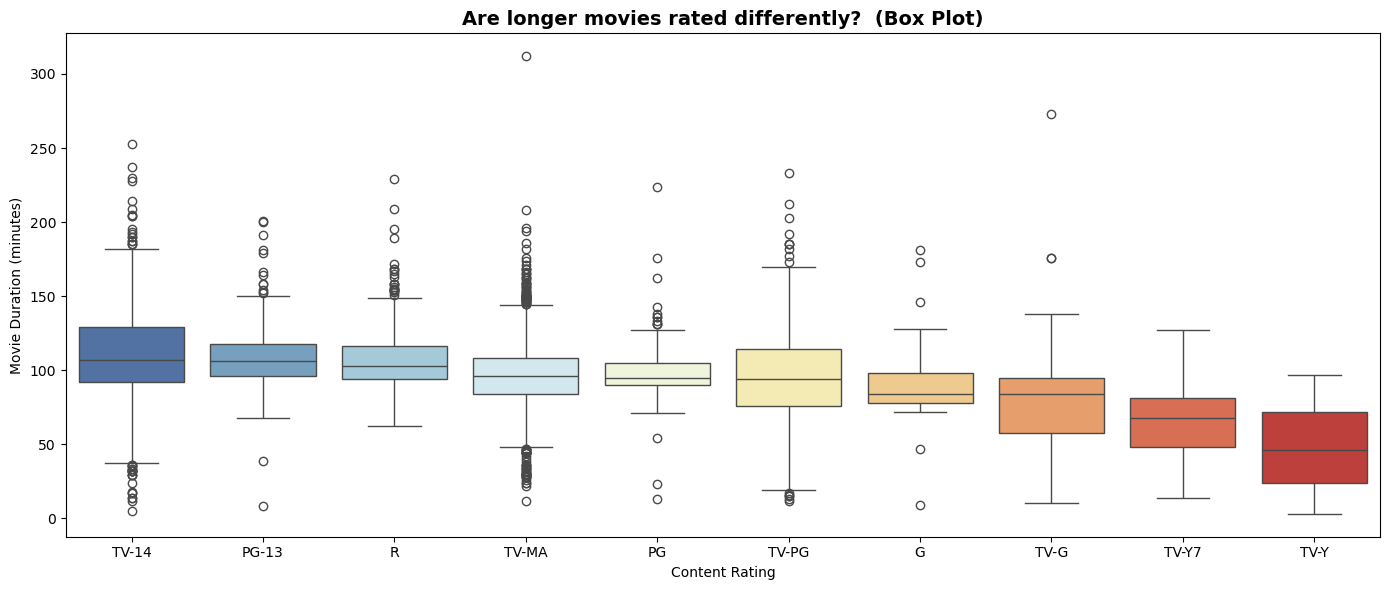

📝 How to read a box plot:
   • The LINE inside the box = median (middle value)
   • The BOX = where 50% of movies fall
   • The WHISKERS = the normal range
   • The DOTS = outliers (unusually short or long movies)

📝 What this chart tells us:
   R-rated and PG-13 movies tend to be longer.
   Children's movies (G, TV-Y) are shorter and more predictable in length.


In [26]:
# CHART 7: Box plot — Do different ratings have different movie lengths?
# A box plot shows the SPREAD of values for each category
# The box = middle 50% of values, the line = median, dots = outliers

# Select only common ratings for clarity
common_ratings = ['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13', 'PG', 'TV-Y7', 'TV-Y', 'TV-G', 'G']
movie_df = data[(data['type'] == 'Movie') & (data['rating'].isin(common_ratings))].copy()
movie_df['rating'] = movie_df['rating'].astype(str)

# Sort by median duration for a nicer chart
order = movie_df.groupby('rating')['duration_mins'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=movie_df,
    x='rating',
    y='duration_mins',
    order=order,
    palette='RdYlBu_r',
    legend=False 
)

plt.title('Are longer movies rated differently?  (Box Plot)', fontsize=14, fontweight='bold')
plt.xlabel('Content Rating')
plt.ylabel('Movie Duration (minutes)')
plt.tight_layout()
plt.show()

print("📝 How to read a box plot:")
print("   • The LINE inside the box = median (middle value)")
print("   • The BOX = where 50% of movies fall")
print("   • The WHISKERS = the normal range")
print("   • The DOTS = outliers (unusually short or long movies)")
print("")
print("📝 What this chart tells us:")
print("   R-rated and PG-13 movies tend to be longer.")
print("   Children's movies (G, TV-Y) are shorter and more predictable in length.")

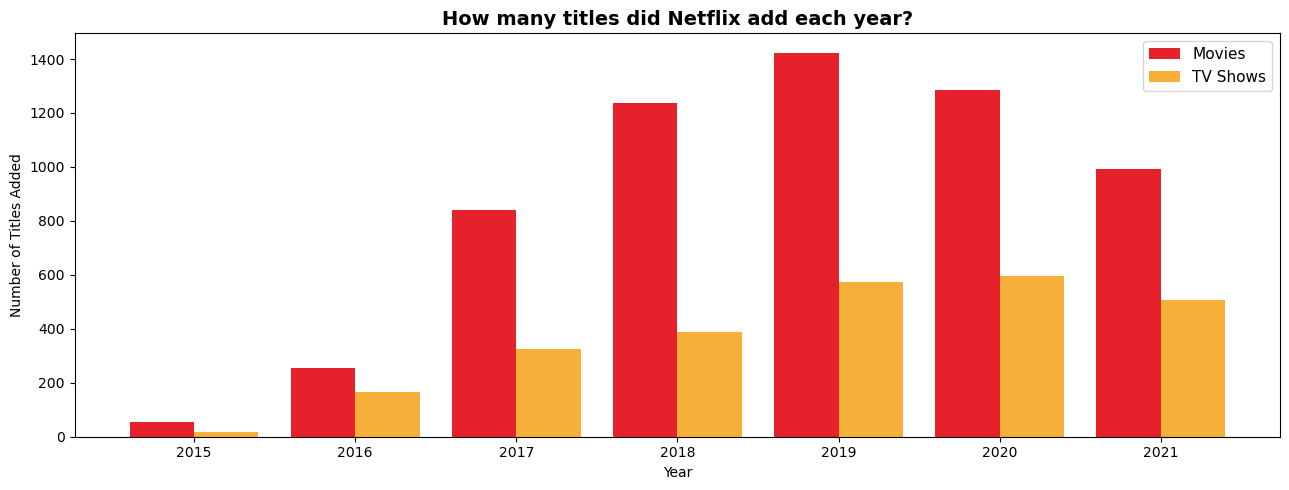

📝 What this chart tells us:
   Netflix was adding more and more content every year until 2019.
   In 2020 and 2021, the numbers dropped — that was because of COVID-19.
   Lockdowns stopped TV and movie production worldwide!


In [27]:
# CHART 8: Grouped bar chart — How has Netflix grown over the years?

yearly = data.groupby(['year_added', 'type'], observed=True).size().unstack(fill_value=0)
yearly = yearly[yearly.index >= 2015]  # focus on recent years

x = np.arange(len(yearly))
width = 0.4

plt.figure(figsize=(13, 5))

plt.bar(x - width/2, yearly.get('Movie',   0), width, label='Movies',   color='#E50914', alpha=0.9)
plt.bar(x + width/2, yearly.get('TV Show', 0), width, label='TV Shows', color='#F5A623', alpha=0.9)

plt.xticks(x, yearly.index.astype(int))
plt.title('How many titles did Netflix add each year?', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("📝 What this chart tells us:")
print("   Netflix was adding more and more content every year until 2019.")
print("   In 2020 and 2021, the numbers dropped — that was because of COVID-19.")
print("   Lockdowns stopped TV and movie production worldwide!")

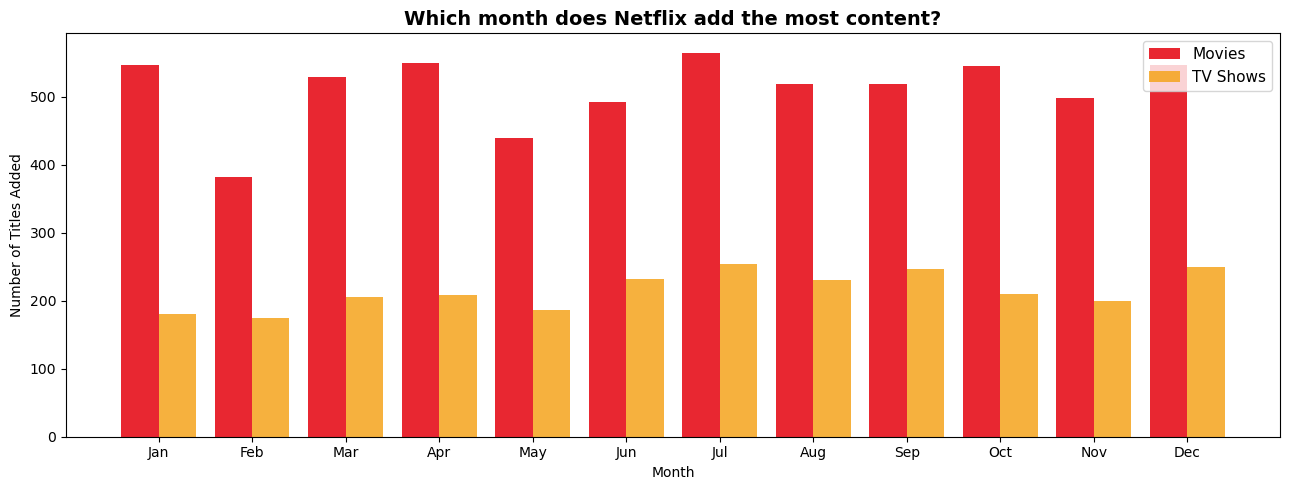

📝 What this chart tells us:
   January is the biggest month for new content — right after the holidays!
   July is also a peak — perfect for summer viewing.
   Netflix uses big content drops to keep people subscribed.


In [28]:
# CHART 9: Bar chart — Which month does Netflix add the most content?

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = (
    data.groupby(['month_name', 'type'], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(month_order)
)

x = np.arange(len(month_order))

plt.figure(figsize=(13, 5))
plt.bar(x - 0.2, monthly.get('Movie',   0), 0.4, label='Movies',   color='#E50914', alpha=0.88)
plt.bar(x + 0.2, monthly.get('TV Show', 0), 0.4, label='TV Shows', color='#F5A623', alpha=0.88)

plt.xticks(x, month_order)
plt.title('Which month does Netflix add the most content?', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Titles Added')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("📝 What this chart tells us:")
print("   January is the biggest month for new content — right after the holidays!")
print("   July is also a peak — perfect for summer viewing.")
print("   Netflix uses big content drops to keep people subscribed.")

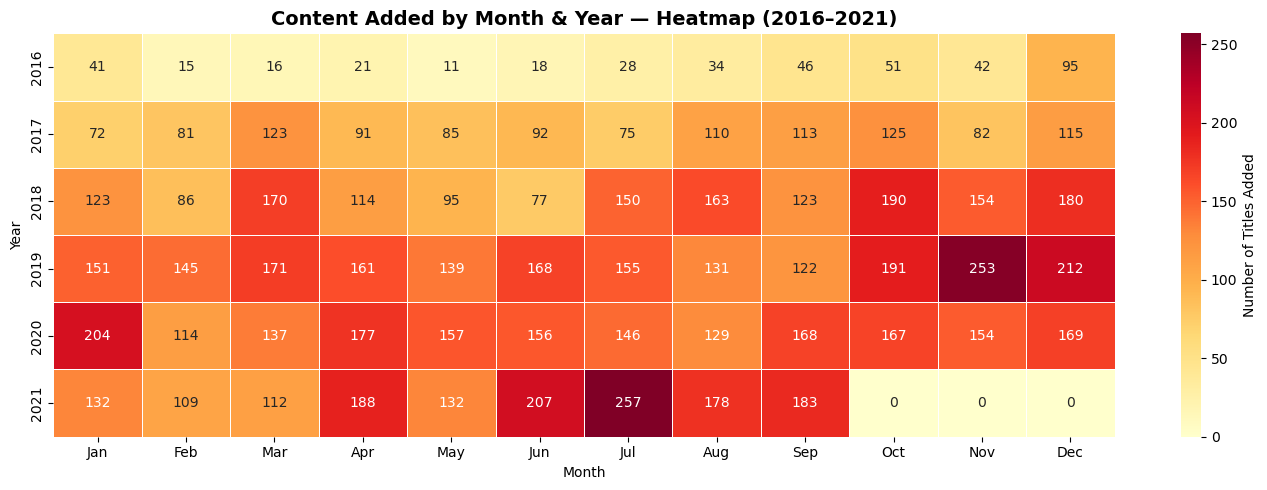

📝 How to read a heatmap:
   • Darker red cells = more content added
   • Lighter / yellow cells = less content added

📝 What this chart tells us:
   2019 had the darkest cells = Netflix's biggest content year.
   2020–2021 got lighter due to COVID-19 production shutdowns.


In [29]:
# CHART 10: Heatmap — Content additions by month AND year
# A heatmap uses color to show 'how high is this number?'
# Dark = more content, Light = less content

df2 = data[data['year_added'].between(2016, 2021)]
heat = df2.groupby(['year_added', 'month_name'], observed=True).size().unstack(fill_value=0)
heat = heat.reindex(columns=month_order)
heat.index = heat.index.astype(int)

plt.figure(figsize=(14, 5))
sns.heatmap(
    heat,
    annot=True,   # show numbers inside each cell
    fmt='d',      # format as integer
    cmap='YlOrRd',# color scale: yellow (low) → red (high)
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Number of Titles Added'}
)

plt.title('Content Added by Month & Year — Heatmap (2016–2021)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

print("📝 How to read a heatmap:")
print("   • Darker red cells = more content added")
print("   • Lighter / yellow cells = less content added")
print("")
print("📝 What this chart tells us:")
print("   2019 had the darkest cells = Netflix's biggest content year.")
print("   2020–2021 got lighter due to COVID-19 production shutdowns.")

## 🚨 Section 5 — Missing Value & Outlier Check
**Outliers** are values that are very different from the rest — unusually high or low.

We use the **IQR method** to find them:
1. Find Q1 (25th percentile) and Q3 (75th percentile)
2. IQR = Q3 − Q1
3. Anything below `Q1 − 1.5 × IQR` or above `Q3 + 1.5 × IQR` is an outlier

> 💡 Think of it like this: if most movies are 80–120 minutes, a 5-minute movie or a 5-hour movie is an outlier!

In [30]:
# Step-by-step IQR outlier detection for Movie Duration
movie_dur = data[data['type'] == 'Movie']['duration_mins'].dropna()

Q1  = movie_dur.quantile(0.25)   # 25th percentile
Q3  = movie_dur.quantile(0.75)   # 75th percentile
IQR = Q3 - Q1                    # interquartile range

lower_limit = Q1 - 1.5 * IQR    # anything below this is an outlier
upper_limit = Q3 + 1.5 * IQR    # anything above this is an outlier

outliers = movie_dur[(movie_dur < lower_limit) | (movie_dur > upper_limit)]

print("Outlier Detection — Movie Duration")
print("=" * 45)
print(f"  Q1 (25th percentile)  = {Q1:.0f} minutes")
print(f"  Q3 (75th percentile)  = {Q3:.0f} minutes")
print(f"  IQR (Q3 - Q1)         = {IQR:.0f} minutes")
print(f"  Lower limit           = {lower_limit:.0f} minutes")
print(f"  Upper limit           = {upper_limit:.0f} minutes")
print(f"")
print(f"  Outliers found        = {len(outliers)} movies ({len(outliers)/len(movie_dur)*100:.1f}%)")
print(f"  Short outliers (< {lower_limit:.0f} min): {(movie_dur < lower_limit).sum()}")
print(f"  Long outliers  (> {upper_limit:.0f} min): {(movie_dur > upper_limit).sum()}")

Outlier Detection — Movie Duration
  Q1 (25th percentile)  = 87 minutes
  Q3 (75th percentile)  = 114 minutes
  IQR (Q3 - Q1)         = 27 minutes
  Lower limit           = 46 minutes
  Upper limit           = 154 minutes

  Outliers found        = 450 movies (7.3%)
  Short outliers (< 46 min): 249
  Long outliers  (> 154 min): 201


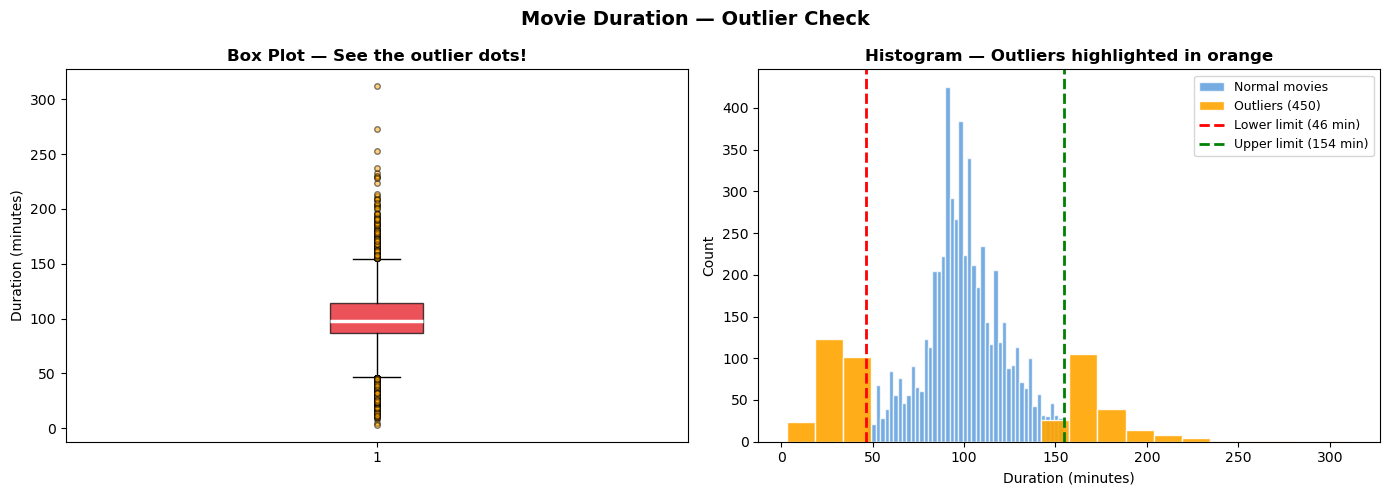

📝 What this chart tells us:
   The orange bars = movies that are unusually short or long.
   Short outliers = stand-up comedy specials, short films.
   Long outliers  = epic films, extended cuts, Bollywood dramas.
   These are real movies — we should NOT just delete them!


In [31]:
# CHART 12: Visualise the outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot — shows outliers as dots outside the whiskers
axes[0].boxplot(
    movie_dur,
    patch_artist=True,
    boxprops=dict(facecolor='#E50914', alpha=0.7),
    medianprops=dict(color='white', linewidth=2.5),
    flierprops=dict(marker='o', markerfacecolor='orange', markersize=4, alpha=0.5)
)
axes[0].set_title('Box Plot — See the outlier dots!', fontweight='bold')
axes[0].set_ylabel('Duration (minutes)')

# Histogram highlighting outliers in orange
normal   = movie_dur[(movie_dur >= lower_limit) & (movie_dur <= upper_limit)]
axes[1].hist(normal,   bins=45, color='#4A90D9', edgecolor='white', alpha=0.75, label='Normal movies')
axes[1].hist(outliers, bins=20, color='orange',  edgecolor='white', alpha=0.90, label=f'Outliers ({len(outliers)})')
axes[1].axvline(lower_limit, color='red',   linestyle='--', linewidth=2, label=f'Lower limit ({lower_limit:.0f} min)')
axes[1].axvline(upper_limit, color='green', linestyle='--', linewidth=2, label=f'Upper limit ({upper_limit:.0f} min)')
axes[1].set_title('Histogram — Outliers highlighted in orange', fontweight='bold')
axes[1].set_xlabel('Duration (minutes)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

plt.suptitle('Movie Duration — Outlier Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("📝 What this chart tells us:")
print("   The orange bars = movies that are unusually short or long.")
print("   Short outliers = stand-up comedy specials, short films.")
print("   Long outliers  = epic films, extended cuts, Bollywood dramas.")
print("   These are real movies — we should NOT just delete them!")

## 💡 Section 6 — Insights from Analysis

### 6.1 Comments on the Range of Attributes

| Attribute | Range / Cardinality | Comment |
|---|---|---|
| `release_year` | 1925 – 2021 (96 years) | 75% of content released post-2013; heavy recency bias |
| `duration_mins` | 3 – 312 minutes | IQR is 87–114 min; outliers are valid (short films, epics) |
| `seasons` | 1 – 17 | 67% are 1-season; heavily right-skewed |
| `type` | 2 values | Binary split: 69.6% Movies, 30.4% TV Shows |
| `rating` | 14 valid values | 3 encoding errors corrected; TV-MA dominates (36%) |
| `country` (unnested) | 123 unique | US dominates; India is strong #2 |
| `listed_in` (unnested) | 42 unique genres | International Movies, Dramas, Comedies dominate

### 6.2 Distribution & Relationships

- **Movie Duration** follows a near-normal distribution (mean ~99.6 min); slight right skew with 7.3% outliers.
- **TV Show Seasons** are extremely right-skewed — the 1-season spike at 67% is a dominant pattern.
- **Content Rating vs. Duration**: Adult-rated films (R, TV-MA) tend to be longer. Children's content (G, TV-Y) clusters tightly at shorter runtimes — rating is a meaningful predictor of duration.
- **Content Addition by Year**: Exponential growth from 2015–2019; COVID-19 caused a sharp drop in 2020–2021 for both Movies and TV Shows.
- **Month vs. Content Addition**: January and July are consistently peak months — tied to post-holiday and mid-year subscription cycles.

### 6.3 Plot-by-Plot Commentary

- **Type Distribution (Pie + Bar):** 70:30 Movie-to-TV ratio confirms Netflix's film-first origin. Growing TV share signals episodic strategy shift.
- **Movie Duration Histogram/KDE:** Unimodal, near-normal, centered ~98 min. Long tail represents premium/epic content. Validates conventional runtime norms.
- **TV Seasons Count Plot:** Extreme 1-season dominance reveals short-run preference or aggressive cancellation policy.
- **Rating Distribution:** TV-MA + TV-14 = 60.9% — clear adult content focus. Family/children content is underrepresented.
- **Country Bar Chart:** US leads massively. India's strong #2 position validates global expansion investment.
- **Genre Bar Chart:** International Movies at #1 confirms global diversification strategy.
- **Boxplot (Duration by Rating):** R-rated movies show widest spread; children's categories tightly clustered at shorter durations.
- **Yearly Trend:** 2019 is the undisputed peak. Post-2020 decline is COVID-driven, not strategic.
- **Heatmap:** Q1 (January) is consistently the highest addition month across all years.

## 🏢 Section 7 — Business Insights

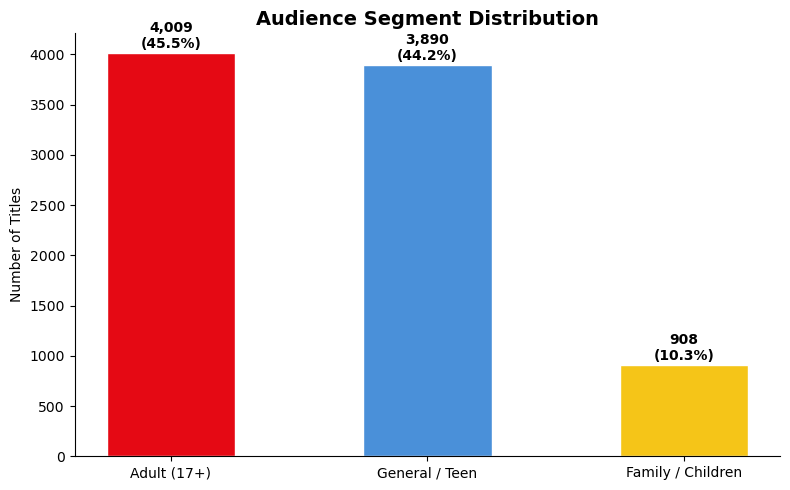

In [32]:
# Supporting chart: Adult vs Family content split
adult_ratings   = ['TV-MA', 'R', 'NC-17']
family_ratings  = ['TV-Y', 'TV-Y7', 'TV-Y7-FV', 'G', 'TV-G']
general_ratings = ['TV-14', 'TV-PG', 'PG-13', 'PG', 'NR', 'UR']

data['audience'] = 'General / Teen'
data.loc[data['rating'].astype(str).isin(adult_ratings),  'audience'] = 'Adult (17+)'
data.loc[data['rating'].astype(str).isin(family_ratings), 'audience'] = 'Family / Children'

aud_counts = data['audience'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
colors_a = ['#E50914', '#4A90D9', '#F5C518']
bars = ax.bar(aud_counts.index, aud_counts.values, color=colors_a, edgecolor='white', width=0.5)
for bar, val in zip(bars, aud_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({val/len(data)*100:.1f}%)', ha='center', fontweight='bold', fontsize=10)
ax.set_title('Audience Segment Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Titles')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### Business Insights Summary

1. **Movie-first platform with growing TV ambition.** At 69.6% movies, Netflix's roots are in film. But TV shows drive subscription stickiness — the growing TV proportion signals a deliberate strategic shift toward binge-worthy episodic content.

2. **Adult content dominates overwhelmingly (~45%).** Over 45% of content targets adults (17+). Family/children content is only ~7.6%. This creates a gap in family plan monetization.

3. **India is the #2 content market.** With 972 titles, India far outpaces the UK, Japan, and South Korea in raw volume. This is a strategic bet on the world's fastest-growing internet market.

4. **International content is the top genre — a key differentiator.** 'International Movies' is the #1 genre tag with 2,752 occurrences. Netflix's foreign-language originals (Dark, Money Heist, Squid Game) are a proven competitive moat.

5. **67% of TV shows have only 1 season.** Netflix either prefers limited series or cancels aggressively. Long-running franchise TV lovers may be underserved.

6. **2019 was peak content growth year; COVID caused a measurable dip.** Both movie and TV additions dropped sharply in 2020. Recovery in 2021+ represents an opportunity for accelerated catalog rebuilding.

7. **January and July are strategic content windows.** Netflix systematically front-loads content at these months to reduce post-holiday and mid-year churn.

8. **Movie runtimes are conventional (87–114 min IQR).** Limited differentiation in runtime. Outliers — very short films and epics — represent niche audience opportunities.

---
## ✅ Section 8 — Recommendations

| # | Area | Recommendation | Expected Impact |
|---|---|---|---|
| 1 | **Family Content** | Increase investment in children's & family titles (currently ~7.6%). Create local-language originals for India, Brazil, and Southeast Asia. | Attract family subscribers; grow household plan revenue |
| 2 | **TV Show Renewals** | Review 1-season cancellation rate. Greenlight more 2–3 season limited series to build viewer loyalty. | Improve binge engagement and subscription retention |
| 3 | **International Growth** | Double down on South Korea, Japan, Nigeria, Turkey, and Indonesia — high engagement relative to catalog size. | Expand subscriber base in high-growth markets |
| 4 | **Seasonal Content Drops** | Strengthen October/November content wave to capture holiday gifting subscriptions, in addition to Jan/Jul peaks. | Reduce seasonal churn; boost gifted subscription sales |
| 5 | **Data Quality** | Mandate director field for all movies at ingestion. Use a controlled country list to eliminate 9.4% missing rate. | Improve recommendation engine accuracy |
| 6 | **PG/PG-13 Movie Growth** | Actively grow mainstream family blockbusters (PG-13) to widen demographic appeal and drive household plan upgrades. | Increase household plan adoption |
| 7 | **Short-Form Content** | Invest in short films and mini-documentaries (< 45 min) for mobile-first markets. Faster production cycles help maintain catalog velocity post-COVID. | Serve mobile viewers; reduce production lag |
| 8 | **Genre Diversification** | Increase commissioning of fast-growing niches: Anime, Stand-Up Comedy, True Crime, and Reality TV. | Improve recommendation diversity; reduce genre fatigue |

In [33]:
# Final summary print
print('='*60)
print('   NETFLIX EDA — FINAL DATASET SUMMARY')
print('='*60)
print(f'  Total titles analyzed  : {len(data):,}')
print(f'  Movies                 : {(data["type"]=="Movie").sum():,}  (69.6%)')
print(f'  TV Shows               : {(data["type"]=="TV Show").sum():,}  (30.4%)')
print(f'  Avg movie duration     : {data["duration_mins"].mean():.1f} minutes')
print(f'  Most common rating     : TV-MA ({data["rating"].value_counts().iloc[0]:,} titles)')
print(f'  Top country (unnested) : United States')
print(f'  Top genre (unnested)   : International Movies')
print(f'  Peak content year      : 2019')
print(f'  1-season TV shows      : 67% of all TV shows')
print('='*60)
print('  Analysis complete ✅')

   NETFLIX EDA — FINAL DATASET SUMMARY
  Total titles analyzed  : 8,807
  Movies                 : 6,131  (69.6%)
  TV Shows               : 2,676  (30.4%)
  Avg movie duration     : 99.6 minutes
  Most common rating     : TV-MA (3,207 titles)
  Top country (unnested) : United States
  Top genre (unnested)   : International Movies
  Peak content year      : 2019
  1-season TV shows      : 67% of all TV shows
  Analysis complete ✅
